In [1]:
import pickle
import networkx as nx
import pandas as pd
import geopandas as gpd
import random

#Import network, origins and destinations
with open(r"C:\Users\luca\Downloads\Lux_public_transport_project\multimodal_network.pkl", "rb") as file:
    multimodal_network = pickle.load(file)

pr_stops  = gpd.read_file(r"C:\Users\luca\Downloads\Lux_public_transport_project\PR_stops.gpkg")
cbd_stops = pd.read_csv(r"C:\Users\luca\Downloads\Lux_public_transport_project\district_candidate_stops.csv")

#Reproject to 2169 for any spatial operations
pr_stops = pr_stops.to_crs(epsg=2169)

In [2]:
#===================================
#Validation checks
#===================================

graph_nodes = set(multimodal_network.nodes())
missing_pr  = set(pr_stops["node"])  - graph_nodes
missing_cbd = set(cbd_stops["node"]) - graph_nodes

#FIX: was `and` — only flagged if BOTH sets had missing nodes, silently ignoring one missing set
if missing_pr or missing_cbd:
    print(f"Missing PR nodes:  {missing_pr}")
    print(f"Missing CBD nodes: {missing_cbd}")

#Check PR and CBD groups
print(f"Central Business Districts are: {cbd_stops['FK_QUART_NAME'].unique().tolist()}")
print(f"P+R stations are: {pr_stops['name'].unique().tolist()}")

#Check a random edge has a weight and that it is within a reasonable range
rand_edge = random.choice(list(multimodal_network.edges(data=True)))
u, v, attrs = rand_edge
print(f"Edge goes from {u} to {v} and has attributes {attrs}")
if ("weight" in attrs) and (attrs["weight"] <= 9999):
    print("Edges are reasonable and functional")

Central Business Districts are: ['Gasperich', 'Gare', 'Kirchberg', 'Ville Haute', 'Grund']
P+R stations are: ['Gare', 'Kockelscheuer', 'Hollerich', 'Howald', 'Stadion', 'Héienhaff']
Edge goes from walk_11515767196 to walk_4144003501 and has attributes {'osmid': 1241770663, 'highway': 'footway', 'oneway': False, 'reversed': True, 'length': 5.656814239191156, 'edge_type': 'walk', 'mode': 'walk', 'weight': 0.06734302665703758}
Edges are reasonable and functional


In [ ]:
import numpy as np

#Group origins and destinations into dictionaries
origin_pr       = pr_stops.groupby("name")["node"].apply(list).to_dict()
destination_cbd = cbd_stops.groupby("FK_QUART_NAME")["node"].apply(list).to_dict()

travel_time_min = {}
for pr, stops in origin_pr.items():

    nodes_stored = {}
    for stop in stops:
        travel_time = nx.single_source_dijkstra_path_length(
            multimodal_network,
            stop,
            cutoff=120,
            weight="weight"
        )

        for node, time in travel_time.items():
            if (node not in nodes_stored) or (time < nodes_stored[node]):
                nodes_stored[node] = time

    travel_time_min[pr] = nodes_stored

# Store [min, mean, max] travel times for each CBD
pr_travel_time = {}

for pr, travel_times in travel_time_min.items():

    pr_travel_time[pr] = {}

    for cbd, cbd_nodes in destination_cbd.items():

        cbd_node_times = [travel_times.get(node, 9999) for node in cbd_nodes]

        reachable = [t for t in cbd_node_times if t != 9999]

        times = [
            np.min(reachable) if reachable else 9999,
            np.mean(reachable) if reachable else 9999,
            np.max(reachable) if reachable else 9999
        ]

        pr_travel_time[pr][cbd] = times

for pr, cbd_dict in pr_travel_time.items():

    cbd_times_reach = [
        [t for t in col if t != 9999]
        for col in zip(*list(cbd_dict.values()))
    ]

    pr_travel_time[pr]["Average Min CBD time"] = np.mean(cbd_times_reach[0]) if cbd_times_reach[0] else 9999
    pr_travel_time[pr]["Average Mean CBD time"] = np.mean(cbd_times_reach[1]) if cbd_times_reach[1] else 9999
    pr_travel_time[pr]["Average Max CBD time"] = np.mean(cbd_times_reach[2]) if cbd_times_reach[2] else 9999

pr_cbd_matrix = (
    pd.DataFrame.from_dict(pr_travel_time, orient="index")
    .reset_index()
    .rename(columns={"index": "P+R Station"})
)

# Heatmap matrix (CBD means only)
cbd_cols = list(destination_cbd.keys())

heatmap_df = pr_cbd_matrix.copy()

for col in cbd_cols:
    heatmap_df[col] = heatmap_df[col].apply(
        lambda x: x[1] if isinstance(x, (list, tuple)) else np.nan
    )

heatmap_df = heatmap_df.set_index("P+R Station")[cbd_cols]



,P+R Station,Gare,Gasperich,Grund,Kirchberg,Ville Haute,Average Min CBD time,Average Mean CBD time,Average Max CBD time
0,Gare,"[0.0, 4.857569062381043, 8.45508076147749]","[8.416666666666668, 15.49686015071536, 19.1028...","[11.0, 12.333333333333332, 13.666666666666666]","[17.790190972404446, 25.713102542094628, 30.66...","[7.1410256410256405, 12.20796176165389, 16.435...",8.869577,14.121765,17.665423
1,Hollerich,"[6.233333333333333, 12.944087223559682, 16.8]","[9.75, 15.148203916361968, 19.773635987311017]","[18.402027803232755, 20.817680568283045, 23.23...","[20.825683144254526, 28.846514800557447, 34.39...","[8.666666666666666, 14.36086142209973, 18.7037...",12.775542,18.423470,22.581776
2,Howald,"[15.199103748696233, 18.19067620496024, 22.233...","[3.9, 10.74336028569631, 16.73824177685094]","[24.835361136566085, 26.947641879024374, 29.05...","[27.532437082029563, 36.04231532689978, 42.653...","[18.69910374869623, 22.975194621247798, 26.668...",18.033201,22.979838,27.470754
3,Héienhaff,"[24.73333333333333, 29.97455264908814, 36.1645...","[40.01538461538461, 44.295035388389515, 48.385...","[29.316666666666663, 29.324916932577764, 29.33...","[7.208333333333333, 15.086896134835733, 24.040...","[22.770908546159983, 27.55857445059309, 33.097...",24.808925,29.247995,34.204088
4,Kockelscheuer,"[18.333333333333336, 25.135486999522026, 28.73...","[9.166666666666666, 15.471764231724467, 23.777...","[30.335361136566085, 32.751013901616375, 35.16...","[36.833333333333336, 45.01242501342954, 50.999...","[26.333333333333336, 32.22574419281095, 36.458...",24.200406,30.119287,35.027045


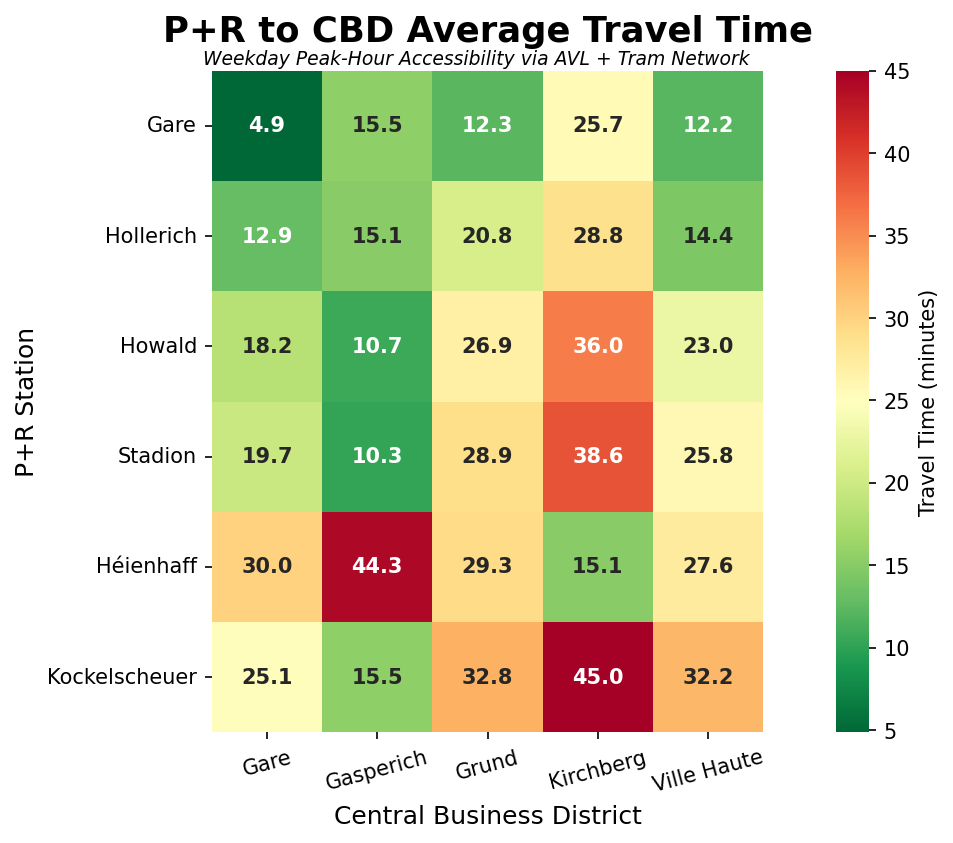

In [4]:
# Heatmap of mean P+R to CBD travel times
import seaborn as sns
import matplotlib.pyplot as plt

plot_matrix = heatmap_df.copy()

row_order = ["Gare", "Hollerich", "Howald", "Stadion", "Héienhaff", "Kockelscheuer"]
plot_matrix = plot_matrix.loc[row_order]

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

sns.heatmap(
    plot_matrix,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    square=True,
    cbar_kws={"label": "Travel Time (minutes)"},
    annot_kws={"size": 10, "weight": "bold"},
    ax=ax
)

ax.set_title("P+R to CBD Average Travel Time", fontsize=17, weight="bold", pad=14)
plt.suptitle("Weekday Peak-Hour Accessibility via AVL + Tram Network", fontsize=9, style="italic", y=0.89, x=0.6)
ax.set_xlabel("Central Business District", fontsize=12)
ax.set_ylabel("P+R Station", fontsize=12)

plt.xticks(rotation=15)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


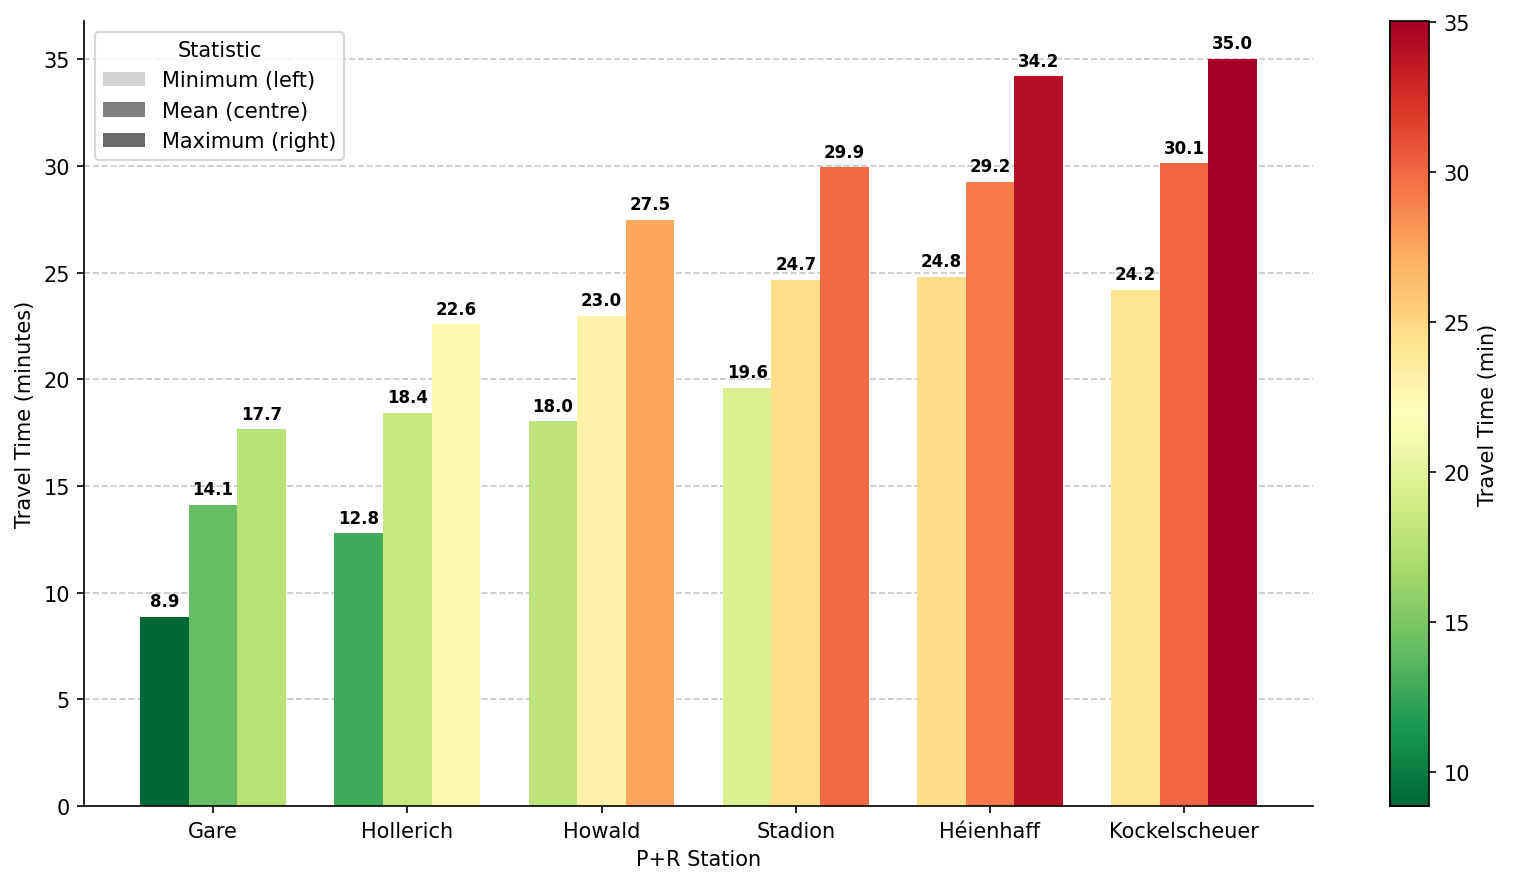

In [5]:
# Grouped min / mean / max accessibility chart
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch

sorted_matrix = pr_cbd_matrix.sort_values(
    "Average Mean CBD time",
    ascending=True
)

stations = sorted_matrix["P+R Station"]

min_times = sorted_matrix["Average Min CBD time"]
mean_times = sorted_matrix["Average Mean CBD time"]
max_times = sorted_matrix["Average Max CBD time"]

x = np.arange(len(stations))
width = 0.25

all_times = np.concatenate([
    min_times.values,
    mean_times.values,
    max_times.values
])

norm = mcolors.Normalize(
    vmin=all_times.min(),
    vmax=all_times.max()
)

colors_min = [cm.RdYlGn_r(norm(v)) for v in min_times]
colors_mean = [cm.RdYlGn_r(norm(v)) for v in mean_times]
colors_max = [cm.RdYlGn_r(norm(v)) for v in max_times]

fig, ax = plt.subplots(figsize=(11, 6), dpi=150)

bars_min = ax.bar(x - width, min_times, width, color=colors_min)
bars_mean = ax.bar(x, mean_times, width, color=colors_mean)
bars_max = ax.bar(x + width, max_times, width, color=colors_max)

for bars in [bars_min, bars_mean, bars_max]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{bar.get_height():.1f}",
            ha="center",
            va="bottom",
            fontsize=8,
            weight="bold"
        )

legend_handles = [
    Patch(facecolor="lightgrey", label="Minimum (left)"),
    Patch(facecolor="grey", label="Mean (centre)"),
    Patch(facecolor="dimgray", label="Maximum (right)")
]

ax.legend(handles=legend_handles, title="Statistic")

sm = ScalarMappable(norm=norm, cmap=cm.RdYlGn_r)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Travel Time (min)")

ax.set_xticks(x)
ax.set_xticklabels(stations)

ax.set_ylabel("Travel Time (minutes)")
ax.set_xlabel("P+R Station")

ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

sns.despine()

plt.tight_layout()
plt.show()


In [6]:
# Ranking robustness and accessibility threshold checks

ranking_df = pd.DataFrame({
    "Min Rank": (
        pr_cbd_matrix
        .sort_values("Average Min CBD time")
        ["P+R Station"]
        .tolist()
    ),
    "Mean Rank": (
        pr_cbd_matrix
        .sort_values("Average Mean CBD time")
        ["P+R Station"]
        .tolist()
    ),
    "Max Rank": (
        pr_cbd_matrix
        .sort_values("Average Max CBD time")
        ["P+R Station"]
        .tolist()
    )
})

print("Ranking comparison\n")
print(ranking_df)
print()

rank_cols = [
    "Average Min CBD time",
    "Average Mean CBD time",
    "Average Max CBD time"
]

rank_comparison = (
    pr_cbd_matrix
    .set_index("P+R Station")[rank_cols]
    .rank(method="dense")
)

rank_comparison["Mean Rank"] = rank_comparison.mean(axis=1)

print("Mean ranking:\n")
print(rank_comparison["Mean Rank"].sort_values())
print()

print("Mean accessibility for each P+R station\n")

for pr, row in heatmap_df.iterrows():
    under_25 = (row < 25).sum()
    print(f"{pr}: {under_25}/5 districts under 25 min")


Ranking comparison

        Min Rank      Mean Rank       Max Rank
0           Gare           Gare           Gare
1      Hollerich      Hollerich      Hollerich
2         Howald         Howald         Howald
3        Stadion        Stadion        Stadion
4  Kockelscheuer      Héienhaff      Héienhaff
5      Héienhaff  Kockelscheuer  Kockelscheuer

Mean ranking:

P+R Station
Gare             1.000000
Hollerich        2.000000
Howald           3.000000
Stadion          4.000000
Héienhaff        5.333333
Kockelscheuer    5.666667
Name: Mean Rank, dtype: float64

Mean accessibility for each P+R station

Gare: 4/5 districts under 25 min
Hollerich: 4/5 districts under 25 min
Howald: 3/5 districts under 25 min
Héienhaff: 1/5 districts under 25 min
Kockelscheuer: 1/5 districts under 25 min
Stadion: 2/5 districts under 25 min


In [ ]:
#Isochrone generation
from shapely.geometry import Point
from shapely.ops import unary_union
import fiona

time_bands = [15, 20, 30, 45]  # minutes

#Extract x,y for every node that has coordinates
node_points = {
    node: (data["x"], data["y"])
    for node, data in multimodal_network.nodes(data=True)
    if ("x" in data) and ("y" in data)
}

#For each P+R station build a buffered isochrone per time band
pr_isochrones = {}
for pr, nodes in travel_time_min.items():
    iso_times_dict = {}
    for iso_time in time_bands:
        iso_nodes  = [node for node, time in nodes.items() if (time <= iso_time) and (node in node_points)]
        iso_points = [Point(node_points[node]) for node in iso_nodes]

        if len(iso_points) < 3:
            print(f"Not enough points for {pr} at {iso_time} min — skipping")
            continue

        graph_crs = multimodal_network.graph["crs"]  # EPSG:2169 — set explicitly in network_creation
        gs = gpd.GeoSeries(iso_points, crs=graph_crs)

        #Smoothed buffered isochrone
        buffered  = gs.buffer(150)
        isochrone = unary_union(buffered)
        isochrone = isochrone.buffer(100).buffer(-100)
        isochrone = isochrone.simplify(20, preserve_topology=True)
        iso_times_dict[iso_time] = isochrone

    pr_isochrones[pr] = iso_times_dict


#When exporting, we have three files: The layers allows you to took look at each isocrhone seperately, atlas combines them all for QGIS atals and the PR copy is also for atlas.


#Seperate isochrone layer
atlas_records = []
for pr, iso_dict in pr_isochrones.items():
    records = []

    for iso_time, geom in iso_dict.items():
        record = {"pr_name": str(pr),"time_min": iso_time,"geometry": geom}
        records.append(record)
        atlas_records.append(record)
        
    gdf = gpd.GeoDataFrame( records,geometry="geometry",crs=graph_crs)
    gdf = gdf.to_crs(4326)
    layer_name = (str(pr).replace(" ", "_").replace("/", "_"))
    gdf.to_file("pr_isochrones_layers.gpkg",layer=layer_name,driver="GPKG")

#combined Atlas layer
atlas_gdf = gpd.GeoDataFrame(atlas_records,geometry="geometry",crs=graph_crs)
atlas_gdf = atlas_gdf.to_crs(4326)
atlas_gdf.to_file("pr_isochrones_atlas.gpkg",layer="isochrones",driver="GPKG")

#PR centroid Atlas layer
pr_stop_records = []
for pr_name, group in pr_stops.groupby("name"):
    centroid = group.geometry.union_all().centroid
    pr_stop_records.append({"pr_name": pr_name,"geometry": centroid})

pr_stops_atlas = gpd.GeoDataFrame(pr_stop_records,geometry="geometry",crs=pr_stops.crs)
pr_stops_atlas = pr_stops_atlas.to_crs(4326)
pr_stops_atlas.to_file("pr_stops_atlas.gpkg",layer="pr_stops",driver="GPKG")


print("\nExport complete:")



Validating Atlas isochrones...
Isochrone Atlas layer validated.

Validating Atlas coverage points...
Coverage layer validated.

Export complete:


✓ All output files exist
✓ Atlas isochrone schema valid
✓ Atlas stop schema valid
✓ Atlas linkage valid
✓ Gare
✓ Hollerich
✓ Howald
✓ Héienhaff
✓ Kockelscheuer
✓ Stadion
Centroid: 49.6126, 6.1284
✓ Coordinates look correct
6 layers found
✓ Layer count correct
✓ Atlas pages will not be empty
